In [36]:
import numpy as np
import scipy.integrate as si
import matplotlib.pyplot as plt
import tensorflow as tf

In [38]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(40, activation='tanh', input_shape=(1,)),  # Capa oculta 1
    tf.keras.layers.Dense(40, activation='tanh'),  # Capa oculta 2
    tf.keras.layers.Dense(40, activation='tanh'),  # Capa oculta 3
    tf.keras.layers.Dense(1)  # Capa de salida
])

In [40]:
type(model)

keras.engine.sequential.Sequential

In [ ]:
np.shape

In [4]:
intervalo=(1,5)
type(intervalo)

tuple

In [8]:
for n in intervalo:
    print(n)


1
5


In [16]:
t_eval=np.linspace(0, 5, 100)
type(t_eval)

numpy.ndarray

In [ ]:
hola= si.solve_ivp

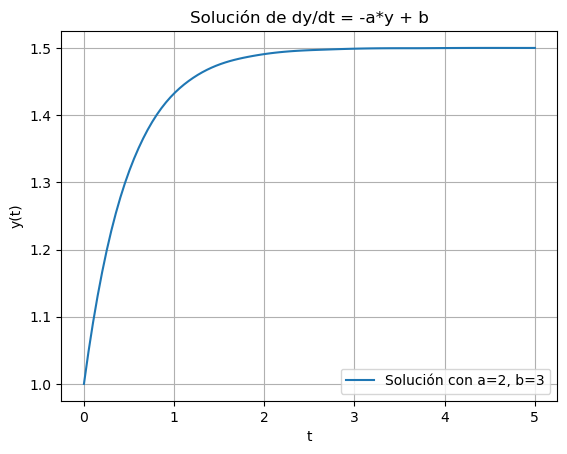

In [32]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Definir la ecuación diferencial con parámetros a y b
def ecuacion_diferencial(t, y, a, b):
    return -a * y + b

# Definir valores de a y b
a = 2
b = 3

# Intervalo de integración y condición inicial
t_span = (0, 5)
y0 = [1]

# Resolver la EDO usando args para pasar (a, b)
sol = solve_ivp(ecuacion_diferencial, t_span, y0, args=(a, b), t_eval=np.linspace(0, 5, 100))

# Graficar la solución
plt.plot(sol.t, sol.y[0], label=f"Solución con a={a}, b={b}")
plt.title("Solución de dy/dt = -a*y + b")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()


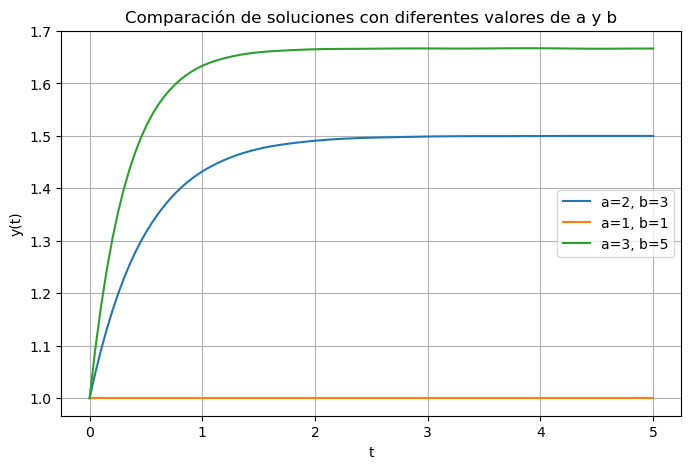

In [34]:
# Definir varios valores de a y b
parametros = [(2, 3), (1, 1), (3, 5)]

# Graficar varias soluciones
plt.figure(figsize=(8, 5))

for a, b in parametros:
    sol = solve_ivp(ecuacion_diferencial, t_span, y0, args=(a, b), t_eval=np.linspace(0, 5, 100))
    plt.plot(sol.t, sol.y[0], label=f"a={a}, b={b}")

plt.title("Comparación de soluciones con diferentes valores de a y b")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()


In [2]:
import tensorflow as tf
import numpy as np

# Definimos la EDO: dy/dx = -2xy
def ode(x, y):
    return -2 * x * y

# Creamos un modelo más simple para este ejemplo
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='tanh', input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

# Array de 3 puntos de entrada de ejemplo
x_train = tf.Variable(np.array([[0.0], [0.5], [1.0]], dtype=np.float32))

# Condición inicial y(0) = 1
x_0 = tf.constant([[0.0]], dtype=tf.float32)
y_0 = tf.constant([[1.0]], dtype=tf.float32)

# Mostramos los pesos iniciales de la red
print("Pesos iniciales de la red:")
for layer in model.layers:
    print(layer.get_weights())

# Función para calcular la pérdida
def compute_loss(x):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)
    dy_dx = tape.gradient(y_pred, x)
    
    # Pérdida de la EDO
    ode_loss = tf.reduce_mean(tf.square(dy_dx - ode(x, y_pred)))
    
    # Pérdida de la condición inicial
    ic_loss = tf.square(model(x_0) - y_0)
    
    return ode_loss + ic_loss

# Un paso de entrenamiento detallado
print("\n--- Primer paso de entrenamiento ---")

# 1. Forward pass
with tf.GradientTape() as tape:
    tape.watch(x_train)
    y_pred = model(x_train)
    print("\nPredicción inicial (y_pred):", y_pred.numpy().flatten())

# 2. Calcular derivadas
dy_dx = tape.gradient(y_pred, x_train)
print("\nDerivada dy/dx calculada:", dy_dx.numpy().flatten())

# 3. Calcular valor de la EDO
ode_val = ode(x_train, y_pred)
print("\nValor de la EDO (-2xy):", ode_val.numpy().flatten())

# 4. Calcular error de la EDO
ode_error = dy_dx - ode_val
print("\nError de la EDO (dy/dx - (-2xy)):", ode_error.numpy().flatten())

# 5. Calcular pérdida de la EDO
ode_loss = tf.reduce_mean(tf.square(ode_error))
print("\nPérdida de la EDO:", ode_loss.numpy())

# 6. Calcular condición inicial
y_pred_0 = model(x_0)
print("\nPredicción en x=0:", y_pred_0.numpy().flatten())

# 7. Error condición inicial
ic_error = y_pred_0 - y_0
print("\nError condición inicial:", ic_error.numpy().flatten())

# 8. Pérdida condición inicial
ic_loss = tf.square(ic_error)
print("\nPérdida condición inicial:", ic_loss.numpy().flatten())

# 9. Pérdida total
total_loss = ode_loss + ic_loss
print("\nPérdida total:", total_loss.numpy().flatten())

# 10. Calcular gradientes
with tf.GradientTape() as tape:
    loss = compute_loss(x_train)
grads = tape.gradient(loss, model.trainable_variables)
print("\nGradientes calculados para los pesos:")

# Mostrar algunos gradientes de ejemplo
for i, grad in enumerate(grads):
    print(f"Capa {i+1} - Forma:", grad.shape)
    print("Algunos valores:", grad.numpy().flatten()[:3], "...\n")

# 11. Aplicar gradientes (usando Adam)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
optimizer.apply_gradients(zip(grads, model.trainable_variables))

print("\nPesos después de una actualización:")
for layer in model.layers:
    print(layer.get_weights())

# --- Después de varias épocas ---
print("\n--- Después de 100 épocas ---")
for epoch in range(100):
    with tf.GradientTape() as tape:
        loss = compute_loss(x_train)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    if epoch % 20 == 0:
        print(f"Época {epoch}: Pérdida = {loss.numpy()}")

# Resultados finales
print("\n--- Resultados finales ---")
print("Entradas x:", x_train.numpy().flatten())
print("Predicciones y:", model(x_train).numpy().flatten())
print("Solución exacta:", np.exp(-x_train.numpy().flatten()**2))
print("Errores absolutos:", np.abs(model(x_train).numpy().flatten() - np.exp(-x_train.numpy().flatten()**2)))

Pesos iniciales de la red:
[array([[ 0.17132741,  0.7141648 , -0.25858766,  0.6331329 , -0.38449076,
         0.15861893, -0.55286187,  0.7318277 ,  0.15788692, -0.00788909]],
      dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)]
[array([[ 0.68305033],
       [ 0.10677123],
       [ 0.71560985],
       [ 0.6830149 ],
       [ 0.20254123],
       [-0.47684017],
       [-0.3562161 ],
       [-0.39185157],
       [-0.17720437],
       [ 0.6619784 ]], dtype=float32), array([0.], dtype=float32)]

--- Primer paso de entrenamiento ---

Predicción inicial (y_pred): [0.         0.07816807 0.13521196]

Derivada dy/dx calculada: [0.16412753 0.14113636 0.08319825]

Valor de la EDO (-2xy): [-0.         -0.07816807 -0.27042392]

Error de la EDO (dy/dx - (-2xy)): [0.16412753 0.21930444 0.35362217]

Pérdida de la EDO: 0.06669364

Predicción en x=0: [0.]

Error condición inicial: [-1.]

Pérdida condición inicial: [1.]

Pérdida total: [1.0666937]

Gradientes calculados pa

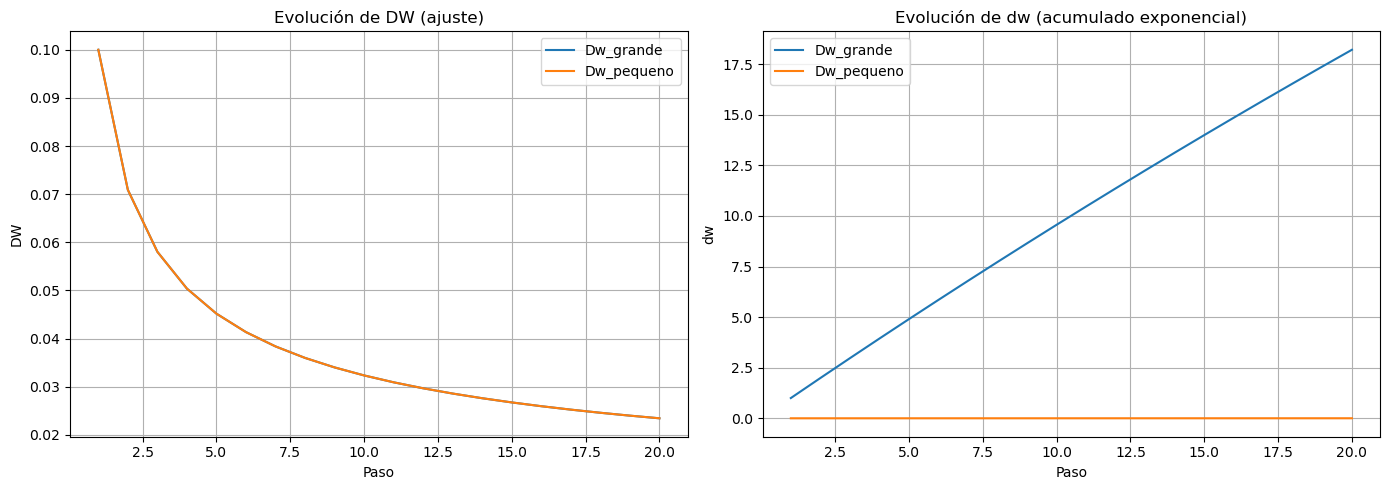

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simular_rmsprop(alpha=0.01, beta=0.99, steps=20):
    # Dos escenarios: gradiente grande y pequeño
    Dw_values = {
        "Dw_grande": 10.0,
        "Dw_pequeno": 0.1
    }

    resultados = {}

    for label, Dw in Dw_values.items():
        dw = 0
        historial = {"step": [], "Dw": [], "dw": [], "DW": []}

        for t in range(1, steps + 1):
            dw = beta * dw + (1 - beta) * (Dw ** 2)
            DW = (alpha * Dw) / np.sqrt(dw)

            historial["step"].append(t)
            historial["Dw"].append(Dw)
            historial["dw"].append(dw)
            historial["DW"].append(DW)

        resultados[label] = pd.DataFrame(historial)

    return resultados

def graficar_resultados(resultados):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    for label, df in resultados.items():
        ax[0].plot(df["step"], df["DW"], label=label)
        ax[1].plot(df["step"], df["dw"], label=label)

    ax[0].set_title("Evolución de DW (ajuste)")
    ax[0].set_xlabel("Paso")
    ax[0].set_ylabel("DW")
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_title("Evolución de dw (acumulado exponencial)")
    ax[1].set_xlabel("Paso")
    ax[1].set_ylabel("dw")
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

# Ejecutar simulación y graficar
resultados = simular_rmsprop()
graficar_resultados(resultados)




In [2]:
!pip install pandas

   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.6 MB 5.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/11.6 MB 6.7 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/11.6 MB 6.7 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.6 MB 6.6 MB/s eta 0:00:02
   --------------------- ------------------ 6.3/11.6 MB 6.7 MB/s eta 0:00:01
   -------------------------- ------------- 7.6/11.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.6 MB 6.7 MB/s eta 0:00:01
   -------------------------------- ------- 9.4/11.6 MB 5.9 MB/s eta 0:00:01
   --------------------------------- ------ 9.7/11.6 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------  11.5/11.6 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 11.6/11.6 MB 5.7 MB/s eta 0:00:00


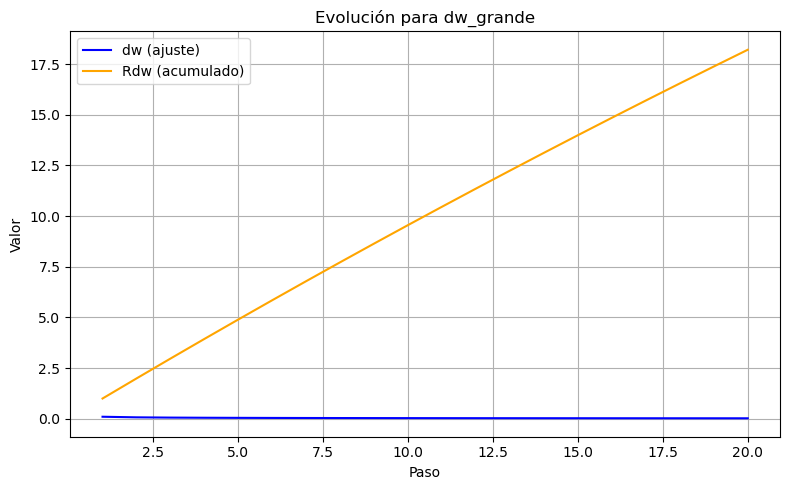

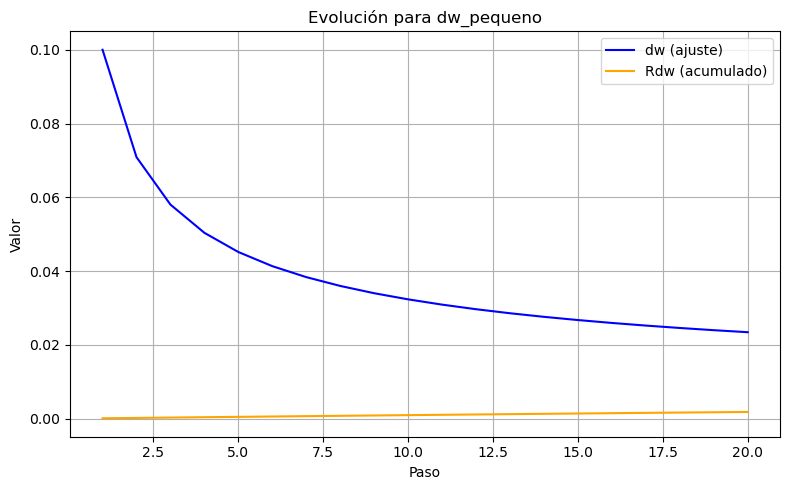

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def simular_rmsprop(alpha=0.01, beta=0.99, steps=20):
    Dw_values = {
        "dw_grande": 10.0,
        "dw_pequeno": 0.1
    }

    resultados = {}

    for label, dw_instantaneo in Dw_values.items():
        Rdw = 0  # inicialización de acumulado
        steps_list = []
        DW_list = []  # valor ajustado
        Rdw_list = []  # acumulado exponencial

        for t in range(1, steps + 1):
            Rdw = beta * Rdw + (1 - beta) * (dw_instantaneo ** 2)
            DW = (alpha * dw_instantaneo) / np.sqrt(Rdw)

            steps_list.append(t)
            DW_list.append(DW)
            Rdw_list.append(Rdw)

        resultados[label] = {
            "steps": steps_list,
            "dw": DW_list,      # el valor ajustado
            "Rdw": Rdw_list     # el promedio acumulado
        }

    return resultados

def graficar_separado(resultados):
    for label, data in resultados.items():
        plt.figure(figsize=(8, 5))
        plt.plot(data["steps"], data["dw"], label="dw (ajuste)", color="blue")
        plt.plot(data["steps"], data["Rdw"], label="Rdw (acumulado)", color="orange")
        plt.title(f"Evolución para {label}")
        plt.xlabel("Paso")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Ejecutar simulación y graficar separados
resultados = simular_rmsprop()
graficar_separado(resultados)


In [1]:
import numpy as np
from scipy.integrate import quad

def integrand(x, a):
    return x**2 * np.log(1 - np.exp(-np.sqrt(x**2 + a**2)))

def V1_beta(a, beta):
    prefactor = 1 / (2 * np.pi**2 * beta**4)
    integral, error = quad(integrand, 0, np.inf, args=(a,))
    return prefactor * integral

# Ejemplo de uso:
a_val = 1.0      # puedes cambiar este valor
beta_val = 1.0   # beta = 1/T, también puedes cambiarlo

resultado = V1_beta(a_val, beta_val)
print(f"V1_beta(a={a_val}, beta={beta_val}) = {resultado}")


V1_beta(a=1.0, beta=1.0) = -0.08594445634282709


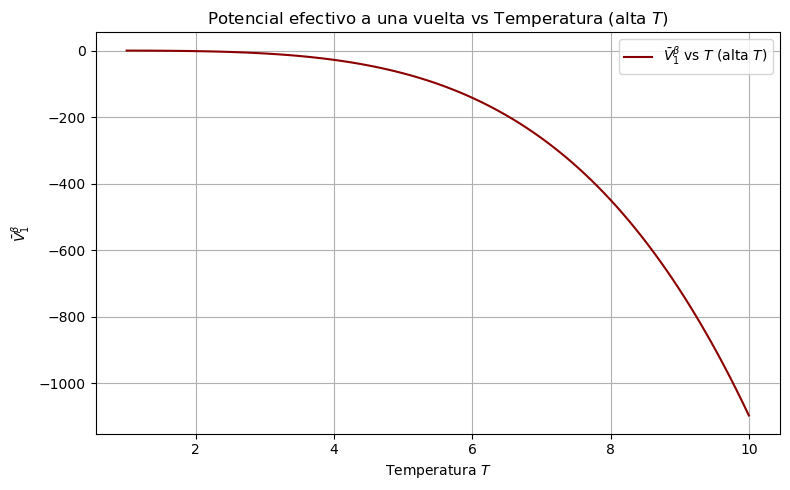

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Parámetros físicos
m = 0.1
lam = 0.5
phi = np.sqrt((m**2 * 6) / lam)  # φ = sqrt((m²·3!)/λ)

# Masa efectiva al cuadrado
def M_squared():
    return m**2 + 0.5 * lam * phi

# Integrando de la integral
def integrand(x, a):
    val = 1 - np.exp(-np.sqrt(x**2 + a**2))
    return x**2 * np.log(val) if val > 0 else 0.0  # evitar log(0)

# Potencial efectivo a una vuelta
def V1_beta(a, beta):
    prefactor = 1 / (2 * np.pi**2 * beta**4)
    integral, _ = quad(integrand, 0, np.inf, args=(a,))
    return prefactor * integral

# Rango de temperaturas altas
T_vals = np.linspace(1.0, 10.0, 100)  # temperatura desde 1 hasta 10
V_vals = []

# Cálculo del potencial para cada T
for T in T_vals:
    beta = 1 / T
    M = np.sqrt(M_squared())
    a = M / T
    V = V1_beta(a, beta)
    V_vals.append(V)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(T_vals, V_vals, label=r"$\bar{V}_1^\beta$ vs $T$ (alta $T$)", color='darkred')
plt.xlabel("Temperatura $T$")
plt.ylabel(r"$\bar{V}_1^\beta$")
plt.title("Potencial efectivo a una vuelta vs Temperatura (alta $T$)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
